New Notebook Created by Jupyter MCP Server

In [1]:
# CELL: 00 初期化・実行管理
from pathlib import Path
import os, sys, json, hashlib, io, warnings, zipfile
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import contextmanager, redirect_stdout, redirect_stderr
import nbformat
REPO = Path('/home/nahisaho/GitHub/jupytermind')
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle as lc
from ai_data_scientist.language_router import detect_language
RUN_ID = 'v020-exp-08'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-08-red-wine')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lc.register_run(RUN_ID, handle.notebook_path)
phase_log = []
@contextmanager
def phase(kind):
    if lc.is_cancel_requested(RUN_ID):
        lc.mark_failed(RUN_ID)
        raise RuntimeError('協調キャンセルを検出しました。')
    start, end = ((lc.mark_execution_start, lc.mark_execution_end) if kind == 'execution'
                  else (lc.mark_write_start, lc.mark_write_end))
    start(RUN_ID)
    phase_log.append({'phase': kind, 'event': 'start', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lc.mark_failed(RUN_ID)
        phase_log.append({'phase': kind, 'event': 'failed', 'time': datetime.now(timezone.utc).isoformat()})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': kind, 'event': 'end', 'time': datetime.now(timezone.utc).isoformat()})
print('言語:', detect_language('品質スコアと化学特性の関係を日本語で分析してください'))
print('run_id:', RUN_ID, '| notebook:', handle.notebook_path)
print('初期状態:', asdict(lc.get_run_status(RUN_ID)))

言語: ja
run_id: v020-exp-08 | notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-08-red-wine/notebooks/kaggle-v020-kaggle-exp-08-red-wine.ipynb
初期状態: {'run_id': 'v020-exp-08', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-08-red-wine/notebooks/kaggle-v020-kaggle-exp-08-red-wine.ipynb', 'reason': None}


In [2]:
# CELL: 01 Kaggle API検索・ファイル取得・出典固定
from ai_data_scientist.ingestion import SourceSpec, ingest
with phase('execution'):
    # SDKや例外が資格情報を出力する可能性を隔離する。秘密を含む生ログは保存しない。
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            search_results = api.dataset_list(search='red wine quality cortez')
            refs = [str(x.ref) for x in search_results]
            slug = 'uciml/red-wine-quality-cortez-et-al-2009'
            if slug not in refs:
                search_results = api.dataset_list(search='red-wine-quality-cortez-et-al-2009')
                refs = [str(x.ref) for x in search_results]
            if slug not in refs:
                raise LookupError('指定の公開データセットがAPI検索結果にありません')
            file_listing = api.dataset_list_files(slug)
            filenames = [str(f.name) for f in file_listing.files]
            filename = 'winequality-red.csv'
            if filename not in filenames:
                raise LookupError('対応するCSVがAPIファイル一覧にありません')
            downloaded = api.dataset_download_file(slug, filename, path=str(data_dir), force=True, quiet=True)
    except Exception as exc:
        lc.mark_failed(RUN_ID)
        print('Kaggle API取得に失敗:', type(exc).__name__, '（資格情報保護のため例外本文を非表示）')
        raise RuntimeError('Kaggle APIによる対象データ確認・取得に失敗。外部CSVにはフォールバックせず停止。') from None
    csv_path = data_dir / filename
    if not csv_path.exists():
        archive = data_dir / (filename + '.zip')
        if not archive.exists():
            raise FileNotFoundError('SDK取得後に対象CSVまたはZIPが見つかりません')
        with zipfile.ZipFile(archive) as z:
            names = z.namelist()
            if filename not in names:
                raise ValueError('ZIP内に対象ファイルがありません')
            csv_path.write_bytes(z.read(filename))
    sha256 = hashlib.sha256(csv_path.read_bytes()).hexdigest()
    previous_path = data_dir / 'provenance.json'
    previous = json.loads(previous_path.read_text()) if previous_path.exists() else None
    if previous is not None and previous['sha256'] != sha256:
        raise RuntimeError('再取得ファイルのSHA-256が前回と異なります。データ更新を確認してから再分析が必要です。')
    provenance = {'owner': 'uciml', 'dataset_slug': slug, 'filename': filename,
                  'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': sha256,
                  'source_url': 'https://www.kaggle.com/datasets/' + slug,
                  'search_terms': ['red wine quality cortez', 'red-wine-quality-cortez-et-al-2009'],
                  'api_calls': ['KaggleApi.authenticate', 'dataset_list', 'dataset_list_files', 'dataset_download_file'],
                  'file_list': filenames, 'matched_reference': slug,
                  'hash_matches_previous': previous is None or previous['sha256'] == sha256}
    loaded = ingest(SourceSpec('csv', str(csv_path)), row_limit=10000)
    df = loaded.dataframe
    if len(df.columns) == 1:
        # ingestのCSV区切り文字オプション不足時だけローカルCSVをSDK取得後に再解釈。
        import pandas as pd
        df = pd.read_csv(csv_path, sep=';')
    if loaded.truncated:
        raise ValueError('予期しない行数制限による切詰めを検出')
    with phase('write'):
        previous_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(provenance, ensure_ascii=False, indent=2))
print('実データ形状:', df.shape)
print('取得ファイル先頭5行:')
display(df.head())

{
  "owner": "uciml",
  "dataset_slug": "uciml/red-wine-quality-cortez-et-al-2009",
  "filename": "winequality-red.csv",
  "retrieved_at_utc": "2026-10-01T16:29:35.314785+00:00",
  "sha256": "d6a0d9bd24806944818795f22500c46cb6424cbff517aacda36595d3ed9b2daa",
  "source_url": "https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009",
  "search_terms": [
    "red wine quality cortez",
    "red-wine-quality-cortez-et-al-2009"
  ],
  "api_calls": [
    "KaggleApi.authenticate",
    "dataset_list",
    "dataset_list_files",
    "dataset_download_file"
  ],
  "file_list": [
    "winequality-red.csv"
  ],
  "matched_reference": "uciml/red-wine-quality-cortez-et-al-2009",
  "hash_matches_previous": true
}
実データ形状: (1599, 12)
取得ファイル先頭5行:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# CELL: 02 データ定義manifest・意味的異常検査・探索
import numpy as np
import pandas as pd
import scipy, scipy.stats as st
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.miscmodels.ordinal_model import OrderedModel
from ai_data_scientist.data_definition import FieldValue, build_manifest
from ai_data_scientist.analysis_assumptions import Assumption, AnalysisAssumptionManifest, check_manifest
from ai_data_scientist.data_quality import detect_anomalies
from ai_data_scientist.cleaning import clean_dataset
from ai_data_scientist.eda import explore
SEED = 200908
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides',
            'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
with phase('execution'):
    assert list(df.columns) == features + ['quality'], '想定スキーマと異なります'
    assert all(pd.api.types.is_numeric_dtype(t) for t in df.dtypes), '非数値列を検出'
    assert np.isfinite(df.to_numpy()).all(), '非有限値を検出'
    units = {'fixed acidity': 'g/dm3（酒石酸換算）', 'volatile acidity': 'g/dm3（酢酸換算）',
             'citric acid': 'g/dm3', 'residual sugar': 'g/dm3', 'chlorides': 'g/dm3（NaCl換算）',
             'free sulfur dioxide': 'mg/dm3', 'total sulfur dioxide': 'mg/dm3',
             'density': 'g/cm3', 'pH': '無次元', 'sulphates': 'g/dm3（K2SO4換算）',
             'alcohol': '体積%', 'quality': '順序尺度スコア'}
    definitions = build_manifest(
        source={k: FieldValue(v, 'verified', '本ノートブックKaggle API取得セル') for k, v in provenance.items()
                if k in ['owner', 'dataset_slug', 'filename', 'retrieved_at_utc', 'sha256', 'source_url']},
        dataset_scope={'population': FieldValue('ポルトガルVinho Verdeの赤ワイン', 'inferred', 'データセット題名・一般的な元データ記述。今回データ辞書で未検証'),
                       'selection': FieldValue('標本抽出方法・生産者・収穫年・評価者ID不明', 'unknown'),
                       'row_identity': FieldValue('1行を1観測記録として扱う。独立試料IDなし', 'unknown')},
        variables={c: {'definition': FieldValue('官能評価の品質順位' if c == 'quality' else c,
                                               'inferred', '列名からの推定'),
                       'unit': FieldValue(units[c], 'inferred', '一般的UCI Wine Quality定義。今回APIファイル一覧のみ検証'),
                       'observed_range': FieldValue([float(df[c].min()), float(df[c].max())], 'verified', '取得CSVの実測')}
                   for c in df.columns},
        transformations=('主解析は全行保持。完全重複除去は感度分析のみ。補完・外れ値削除なし。',))
    unresolved = [(key, asdict(value)) for key, value in definitions.unresolved_fields()]
    inferred = [f'variables.{c}.{k}' for c, fields in definitions.variables.items()
                for k, v in fields.items() if v.status == 'inferred']
    schema = {c: {'min': 0, 'not_null': True} for c in features}
    schema.update({'pH': {'min': 0, 'max': 14, 'not_null': True},
                   'alcohol': {'min': 0, 'max': 100, 'not_null': True},
                   'density': {'min': 0, 'not_null': True},
                   'quality': {'allowed': list(range(11)), 'not_null': True}})
    anomalies = detect_anomalies(df, schema)
    cross_invalid = int((df['free sulfur dioxide'] > df['total sulfur dioxide']).sum())
    unique_report = clean_dataset(df, operation='drop_duplicates')
    unique_df = unique_report.dataframe.copy()
    eda_result = explore(df)
    quality_counts = df['quality'].value_counts().sort_index().rename_axis('quality').reset_index(name='count')
    quality_counts['fraction'] = quality_counts['count'] / len(df)
    semantic_report = {'n': len(df), 'p': len(features), 'missing': int(df.isna().sum().sum()),
                       'schema_violations': [asdict(a) for a in anomalies],
                       'free_gt_total_SO2': cross_invalid, 'duplicate_rows_removed_if_deduplicated': unique_report.rows_removed,
                       'unique_rows': len(unique_df), 'integer_quality': bool((df['quality'] % 1 == 0).all()),
                       'schema_bounds_status': '物理的広域範囲・quality 0..10は分析者の暫定仮定。専門的正常範囲ではない'}
    assert not anomalies and cross_invalid == 0 and semantic_report['integer_quality']
    with phase('write'):
        (data_dir / 'data-definition-manifest.json').write_text(json.dumps(asdict(definitions), ensure_ascii=False, indent=2), encoding='utf-8')
print('意味的異常検査:', json.dumps(semantic_report, ensure_ascii=False, indent=2))
print('未解決定義:', json.dumps(unresolved, ensure_ascii=False))
print('推定のままの定義・単位（verifiedへ昇格しない）:', inferred)
print('データ定義manifest:')
print(json.dumps(asdict(definitions), ensure_ascii=False, indent=2))
print('品質度数:')
display(quality_counts)
print('全列の記述統計:')
display(df.describe().T)
print('EDAモジュール結果:')
print(eda_result)
print('実行環境:', {'python': sys.version.split()[0], 'pandas': pd.__version__, 'numpy': np.__version__,
                     'scipy': scipy.__version__, 'statsmodels': sm.__version__})

意味的異常検査: {
  "n": 1599,
  "p": 11,
  "missing": 0,
  "schema_violations": [],
  "free_gt_total_SO2": 0,
  "duplicate_rows_removed_if_deduplicated": 240,
  "unique_rows": 1359,
  "integer_quality": true,
  "schema_bounds_status": "物理的広域範囲・quality 0..10は分析者の暫定仮定。専門的正常範囲ではない"
}
未解決定義: [["dataset_scope.selection", {"value": "標本抽出方法・生産者・収穫年・評価者ID不明", "status": "unknown", "source": null}], ["dataset_scope.row_identity", {"value": "1行を1観測記録として扱う。独立試料IDなし", "status": "unknown", "source": null}]]
推定のままの定義・単位（verifiedへ昇格しない）: ['variables.fixed acidity.definition', 'variables.fixed acidity.unit', 'variables.volatile acidity.definition', 'variables.volatile acidity.unit', 'variables.citric acid.definition', 'variables.citric acid.unit', 'variables.residual sugar.definition', 'variables.residual sugar.unit', 'variables.chlorides.definition', 'variables.chlorides.unit', 'variables.free sulfur dioxide.definition', 'variables.free sulfur dioxide.unit', 'variables.total sulfur dioxide.definition', 'var

,quality,count,fraction
0,3,10,0.006254
1,4,53,0.033146
2,5,681,0.425891
3,6,638,0.398999
4,7,199,0.124453
5,8,18,0.011257


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [4]:
# CELL: 03 初回解析・単変量関連・調整済み関連
from ai_data_scientist.stats_analysis import correlation
with phase('execution'):
    rows = []
    pearson_interpretations = {}
    for col in features:
        pearson = correlation(df, col, 'quality', language='ja')
        rho, p = st.spearmanr(df[col], df['quality'])
        rows.append({'feature': col, 'pearson_r': pearson.statistic, 'pearson_p': pearson.p_value,
                     'spearman_rho': float(rho), 'spearman_p': float(p)})
        pearson_interpretations[col] = pearson.interpretation
    correlations = pd.DataFrame(rows).set_index('feature')
    correlations['spearman_q_BH_11'] = multipletests(correlations['spearman_p'], method='fdr_bh')[1]
    correlations = correlations.sort_values('spearman_rho', key=abs, ascending=False)
    focal = ['alcohol', 'volatile acidity', 'sulphates']
    rng = np.random.default_rng(SEED)
    bootstrap = {c: [] for c in focal}
    for b in range(1200):
        sample = unique_df.iloc[rng.integers(0, len(unique_df), len(unique_df))]
        for c in focal:
            bootstrap[c].append(float(st.spearmanr(sample[c], sample['quality']).statistic))
    bootstrap_ci = pd.DataFrame([
        {'feature': c, 'unique_spearman': float(st.spearmanr(unique_df[c], unique_df['quality']).statistic),
         'ci_low': float(np.quantile(bootstrap[c], .025)), 'ci_high': float(np.quantile(bootstrap[c], .975))}
        for c in focal]).set_index('feature')
    means, sds = df[features].mean(), df[features].std(ddof=0)
    Z = (df[features] - means) / sds
    groups = df.groupby(features, dropna=False).ngroup()
    ols = sm.OLS(df['quality'], sm.add_constant(Z)).fit(cov_type='cluster', cov_kwds={'groups': groups})
    ols_ci = ols.conf_int()
    adjusted = pd.DataFrame({'coefficient_per_SD': ols.params, 'ci_low': ols_ci[0], 'ci_high': ols_ci[1], 'p_cluster': ols.pvalues}).drop('const')
    adjusted['q_BH_11'] = multipletests(adjusted['p_cluster'], method='fdr_bh')[1]
    adjusted['VIF'] = [variance_inflation_factor(Z.to_numpy(), i) for i in range(len(features))]
    # R2は同一標本内の記述的適合度。汎化予測力ではない。
    group_summary = df.groupby('quality')[focal].agg(['count', 'median', 'mean'])
    assumptions = AnalysisAssumptionManifest(
        analysis_scope={'outcome': 'quality（順序尺度）', 'features': features,
                        'primary': '全行Spearman+Pearson、全11特性調整OLS、完全一致化学特性でクラスタ標準誤差',
                        'secondary': '重複除去・順位モデル・中心品質帯・極端値処理の感度分析'},
        causal_scope='associational',
        assumptions=(
            Assumption('no-causal-identification', '観察データで交絡統制・操作介入の識別条件なし。因果主張しない', 'verified', conclusion_critical=True),
            Assumption('duplicate-policy', '全行を保持するが重複の影響は除去版と比較する', 'tested', conclusion_critical=True),
            Assumption('iid-between-profiles', '化学特性が異なる観測群は独立。試料・生産者IDがなく検証できない', 'assumed',
                       impact_if_false='CIやp値が過度に精密になる。母集団への推論は限定', conclusion_critical=True),
            Assumption('ordinal-metric', 'OLSはスコア間隔を同等と近似する。順位モデルで後続検査', 'assumed',
                       impact_if_false='係数の量的解釈に依存。順位方向を中心に判断', conclusion_critical=True),
            Assumption('generalizability', '任意の赤ワイン全体を代表するとは仮定しない', 'verified'),
            Assumption('physical-bounds', '意味検査の広い物理的範囲は専門的正常値判定ではない', 'assumed')),
        sampling={'n': len(df), 'seed': SEED, 'bootstrap_replicates': 1200})
    assumption_findings = check_manifest(assumptions)
    initial_metrics = {'n': len(df), 'unique_n': len(unique_df), 'duplicates': unique_report.rows_removed,
        'quality_5_6_fraction': float(df['quality'].isin([5, 6]).mean()),
        'spearman_alcohol': float(correlations.loc['alcohol', 'spearman_rho']),
        'spearman_volatile_acidity': float(correlations.loc['volatile acidity', 'spearman_rho']),
        'spearman_sulphates': float(correlations.loc['sulphates', 'spearman_rho']),
        'ols_r2_in_sample': float(ols.rsquared),
        'adjusted_alcohol_per_SD': float(adjusted.loc['alcohol', 'coefficient_per_SD']),
        'adjusted_volatile_acidity_per_SD': float(adjusted.loc['volatile acidity', 'coefficient_per_SD']),
        'adjusted_sulphates_per_SD': float(adjusted.loc['sulphates', 'coefficient_per_SD'])}
    with phase('write'):
        (data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions), ensure_ascii=False, indent=2), encoding='utf-8')
print('初回主要数値:', json.dumps(initial_metrics, ensure_ascii=False, indent=2))
print('全11特性の相関（Spearmanを主としBH補正。p値は探索的・行独立近似）:')
display(correlations)
print('Jupytermind Pearson解釈（因果解釈ではない）:', json.dumps(pearson_interpretations, ensure_ascii=False))
print('重複除去版のSpearman 95% percentile bootstrap CI（試料独立仮定）:')
display(bootstrap_ci)
print('全11特性を同時調整したOLS関連（1 SD差、重複特性クラスタSE、BH補正）:')
display(adjusted)
print('品質別の記述統計:')
display(group_summary)
print('分析前提manifest:', json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))
print('前提検査の全所見:', json.dumps([asdict(f) for f in assumption_findings], ensure_ascii=False, indent=2))

初回主要数値: {
  "n": 1599,
  "unique_n": 1359,
  "duplicates": 240,
  "quality_5_6_fraction": 0.8248905565978737,
  "spearman_alcohol": 0.47853168747024344,
  "spearman_volatile_acidity": -0.3806465104253755,
  "spearman_sulphates": 0.37706019910212196,
  "ols_r2_in_sample": 0.36055170303868844,
  "adjusted_alcohol_per_SD": 0.2942428826624262,
  "adjusted_volatile_acidity_per_SD": -0.19396667018958688,
  "adjusted_sulphates_per_SD": 0.15527650155577583
}
全11特性の相関（Spearmanを主としBH補正。p値は探索的・行独立近似）:
Jupytermind Pearson解釈（因果解釈ではない）: {"fixed acidity": "相関係数は 0.1241 (p=6.496e-07) で、弱い正の相関が見られます。", "volatile acidity": "相関係数は -0.3906 (p=2.052e-59) で、中程度の負の相関が見られます。", "citric acid": "相関係数は 0.2264 (p=4.991e-20) で、弱い正の相関が見られます。", "residual sugar": "相関係数は 0.0137 (p=0.5832) で、弱い正の相関が見られます。", "chlorides": "相関係数は -0.1289 (p=2.313e-07) で、弱い負の相関が見られます。", "free sulfur dioxide": "相関係数は -0.0507 (p=0.04283) で、弱い負の相関が見られます。", "total sulfur dioxide": "相関係数は -0.1851 (p=8.622e-14) で、弱い負の相関が見られます。", "density": "相関係数は

,pearson_r,pearson_p,spearman_rho,spearman_p,spearman_q_BH_11
feature,,,,,
alcohol,0.476166,2.831477e-91,0.478532,2.726838e-92,2.999522e-91
volatile acidity,-0.390558,2.051715e-59,-0.380647,2.734944e-56,1.504219e-55
sulphates,0.251397,1.802088e-24,0.377060,3.477695e-55,1.275155e-54
citric acid,0.226373,4.991295e-20,0.213481,6.158952e-18,1.693712e-17
total sulfur dioxide,-0.185100,8.621703e-14,-0.196735,2.046488e-15,4.502273e-15
chlorides,-0.128907,2.313383e-07,-0.189922,1.882858e-14,3.451906e-14
density,-0.174919,1.874957e-12,-0.177074,9.918139e-13,1.558565e-12
fixed acidity,0.124052,6.495635e-07,0.114084,4.801220e-06,6.601677e-06
free sulfur dioxide,-0.050656,4.283398e-02,-0.056901,2.288322e-02,2.796838e-02


,unique_spearman,ci_low,ci_high
feature,,,
alcohol,0.487965,0.443804,0.529599
volatile acidity,-0.387450,-0.433335,-0.339624
sulphates,0.380581,0.334415,0.425468


,coefficient_per_SD,ci_low,ci_high,p_cluster,q_BH_11,VIF
fixed acidity,0.043497,-0.078196,0.165191,4.835788e-01,5.165350e-01,7.767512
volatile acidity,-0.193967,-0.245149,-0.142784,1.104894e-13,6.076917e-13,1.789390
citric acid,-0.035553,-0.101088,0.029983,2.876625e-01,3.955360e-01,3.128022
residual sugar,0.023019,-0.034250,0.080287,4.308163e-01,5.165350e-01,1.702588
chlorides,-0.088183,-0.134756,-0.041611,2.063611e-04,4.539943e-04,1.481932
free sulfur dioxide,0.045606,-0.004528,0.095740,7.459548e-02,1.194256e-01,1.963019
total sulfur dioxide,-0.107356,-0.160122,-0.054590,6.672072e-05,1.834820e-04,2.186813
density,-0.033737,-0.135670,0.068196,5.165350e-01,5.165350e-01,6.343760
pH,-0.063842,-0.134362,0.006677,7.599810e-02,1.194256e-01,3.329732
sulphates,0.155277,0.107500,0.203053,1.889966e-10,6.929876e-10,1.429434


alcohol                    volatile acidity                   \
          count  median       mean            count median      mean   
quality                                                                
3            10   9.925   9.955000               10  0.845  0.884500   
4            53  10.000  10.265094               53  0.670  0.693962   
5           681   9.700   9.899706              681  0.580  0.577041   
6           638  10.500  10.629519              638  0.490  0.497484   
7           199  11.500  11.465913              199  0.370  0.403920   
8            18  12.150  12.094444               18  0.370  0.423333   

        sulphates                   
            count median      mean  
quality                             
3              10  0.545  0.570000  
4              53  0.560  0.596415  
5             681  0.580  0.620969  
6             638  0.640  0.675329  
7             199  0.740  0.741256  
8              18  0.740  0.767778

図表ログ: [
  {
    "title": "品質スコアの分布",
    "xlabel": "品質スコア",
    "ylabel": "観測数",
    "legend": "count: 観測数",
    "missing_glyphs": [],
    "png_sha256": "59c305cd81fa7fa755c8df13c79a7da63b77e66c7e0ee3d0fff3648988f6d3a7",
    "png_bytes": 18306
  },
  {
    "title": "品質と化学特性：Spearman相関",
    "xlabel": "順位相関係数 rho",
    "ylabel": "化学特性",
    "legend": "青:正、橙:負。単一系列",
    "missing_glyphs": [],
    "png_sha256": "f0e40b7f37008c25096ccdcab4440553e84e84bff7a610329606a877ca98fc84",
    "png_bytes": 43078
  },
  {
    "title": "品質別の主要特性分布",
    "xlabel": "品質スコア",
    "ylabel": "測定値（単位未検証）",
    "legend": "箱:25-75%、線:中央値、丸:1.5IQR外",
    "missing_glyphs": [],
    "png_sha256": "cd348d1d7994ea79e5ef8fa85711b4b94faea70cbb740f2bbbeb673e1d3fcf9a",
    "png_bytes": 100939
  },
  {
    "title": "調整済みOLS関連",
    "xlabel": "品質スコア差 / 1 SD",
    "ylabel": "化学特性",
    "legend": "係数と95%クラスタCI",
    "missing_glyphs": [],
    "png_sha256": "0b8c92148d4107343b71f2b2a9a3de7f43995dd16120ffd43312fa323dc78881",
  

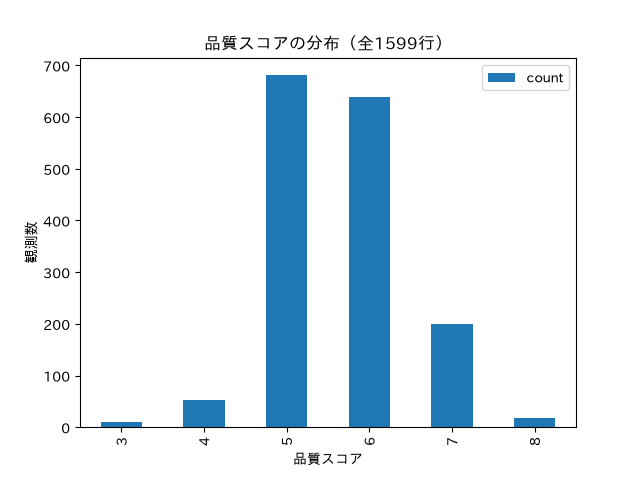

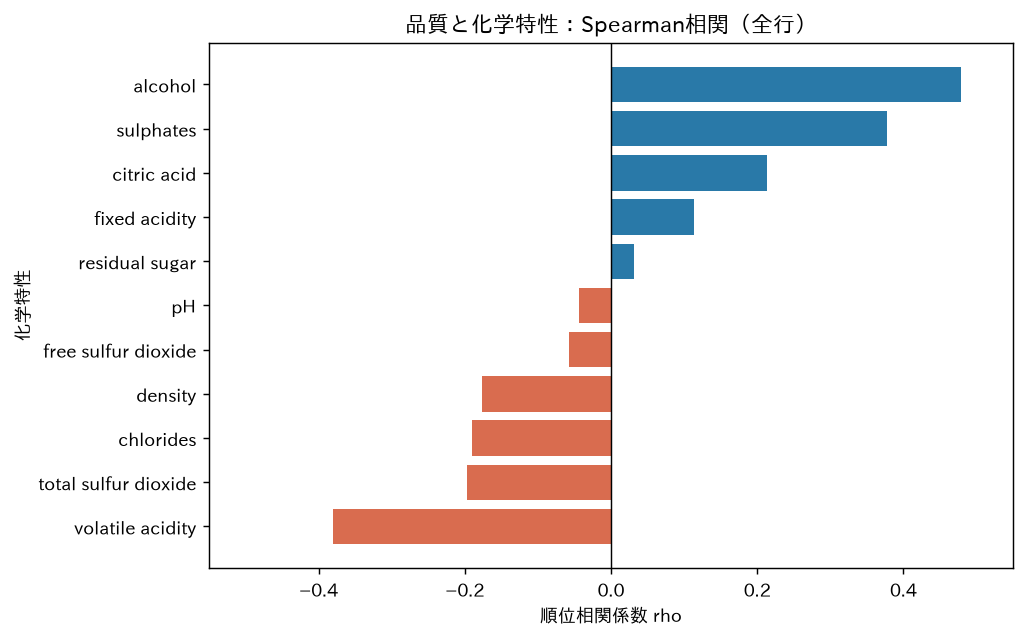

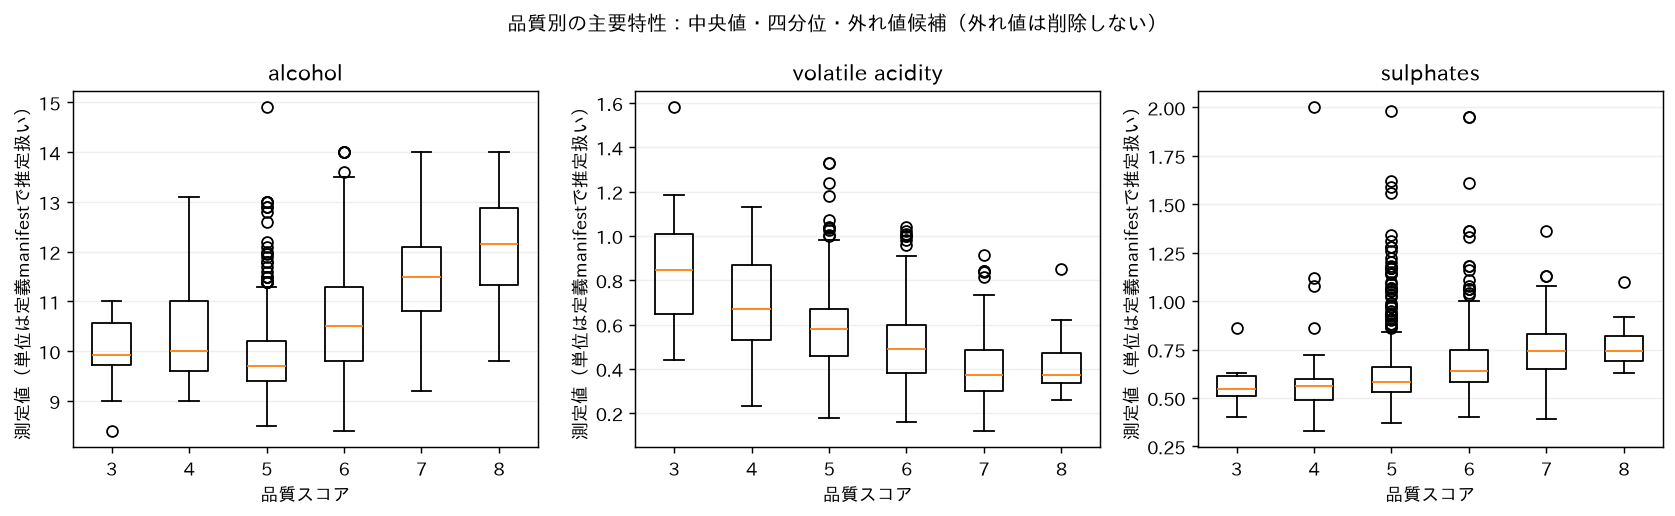

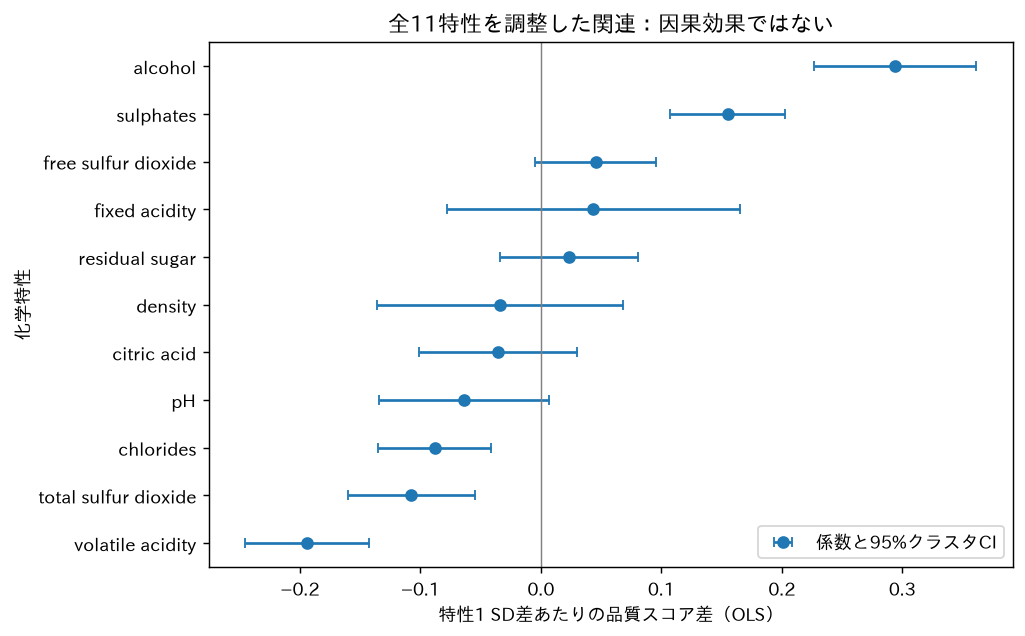

In [6]:
# CELL: 04 図表・描画メタデータ
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
from ai_data_scientist.visualization import render_chart, build_image_output
chart_log = []
def show_png(png, title, xlabel, ylabel, legend):
    out = build_image_output(png)
    meta = {'title': title, 'xlabel': xlabel, 'ylabel': ylabel, 'legend': legend, 'missing_glyphs': []}
    display(out['data'], raw=True, metadata={'chart': meta})
    chart_log.append({**meta, 'png_sha256': hashlib.sha256(png).hexdigest(), 'png_bytes': len(png)})
def finish_plot(fig, title, xlabel, ylabel, legend):
    buff = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buff, format='png', dpi=130, bbox_inches='tight')
    plt.close(fig)
    show_png(buff.getvalue(), title, xlabel, ylabel, legend)
with phase('execution'):
    with warnings.catch_warnings(record=True) as visual_warnings:
        warnings.simplefilter('always')
        png = render_chart(quality_counts, kind='bar', x='quality', y='count',
                           title='品質スコアの分布（全1599行）', xlabel='品質スコア', ylabel='観測数')
        show_png(png, '品質スコアの分布', '品質スコア', '観測数', 'count: 観測数')
        fig, ax = plt.subplots(figsize=(8, 5))
        plot_corr = correlations.sort_values('spearman_rho')
        ax.barh(plot_corr.index, plot_corr['spearman_rho'], color=np.where(plot_corr['spearman_rho'] > 0, '#2979a8', '#d96c4f'))
        ax.axvline(0, color='black', lw=.8)
        ax.set(title='品質と化学特性：Spearman相関（全行）', xlabel='順位相関係数 rho', ylabel='化学特性')
        ax.set_xlim(-.55, .55)
        finish_plot(fig, '品質と化学特性：Spearman相関', '順位相関係数 rho', '化学特性', '青:正、橙:負。単一系列')
        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        levels = sorted(df['quality'].unique())
        for ax, col in zip(axes, focal):
            ax.boxplot([df.loc[df['quality'] == q, col].to_numpy() for q in levels], tick_labels=[str(q) for q in levels], showfliers=True)
            ax.set(title=col, xlabel='品質スコア', ylabel='測定値（単位は定義manifestで推定扱い）')
            ax.grid(axis='y', alpha=.2)
        fig.suptitle('品質別の主要特性：中央値・四分位・外れ値候補（外れ値は削除しない）', fontsize=11)
        finish_plot(fig, '品質別の主要特性分布', '品質スコア', '測定値（単位未検証）', '箱:25-75%、線:中央値、丸:1.5IQR外')
        fig, ax = plt.subplots(figsize=(8, 5))
        coef = adjusted.sort_values('coefficient_per_SD')
        ax.errorbar(coef['coefficient_per_SD'], np.arange(len(coef)),
                    xerr=np.vstack([coef['coefficient_per_SD']-coef['ci_low'], coef['ci_high']-coef['coefficient_per_SD']]),
                    fmt='o', capsize=3, label='係数と95%クラスタCI')
        ax.set_yticks(np.arange(len(coef)), labels=coef.index)
        ax.axvline(0, color='gray', lw=.8)
        ax.set(title='全11特性を調整した関連：因果効果ではない', xlabel='特性1 SD差あたりの品質スコア差（OLS）', ylabel='化学特性')
        ax.legend(loc='lower right')
        finish_plot(fig, '調整済みOLS関連', '品質スコア差 / 1 SD', '化学特性', '係数と95%クラスタCI')
    glyph_messages = [str(w.message) for w in visual_warnings if 'Glyph' in str(w.message)]
    if glyph_messages:
        raise RuntimeError('図表に未描画グリフを検出: ' + '; '.join(glyph_messages))
print('図表ログ:', json.dumps(chart_log, ensure_ascii=False, indent=2))
print('描画警告（グリフ欠落なし）:', [str(w.message) for w in visual_warnings])

In [7]:
# CELL: 05 反復1：重複・極端値・相関定義の感度分析
from ai_data_scientist.sensitivity import SensitivityPlan, run_sensitivity
iteration_history = []
request1 = '完全重複240行と極端な化学特性値が主要な関連を作っていないか確認してください。全行／完全重複除去、無処理／各特性の上下1%ウィンザー化、Spearman／Pearsonの組合せでアルコール・揮発性酸度・硫酸塩の関連の方向と大きさを比較し、安定性と限界を報告してください。'
iteration_history.append({'iteration': 1, 'request': request1,
    'reason': '完全重複と硫酸塩のPearson/Spearman差が初回結果の解釈と不確実性に影響するため',
    'selection_evidence': {'duplicate_rows': unique_report.rows_removed, 'sulphates_pearson': float(correlations.loc['sulphates', 'pearson_r']),
                           'sulphates_spearman': float(correlations.loc['sulphates', 'spearman_rho'])}})
with phase('execution'):
    sensitivity_plan = SensitivityPlan(parameter_grid={'deduplicate': [False, True], 'winsorize': [False, True],
                                                       'method': ['spearman', 'pearson']}, max_runs=8)
    sensitivity_reports = {}
    sensitivity_rows = []
    for col in focal:
        def analysis_fn(deduplicate, winsorize, method, column=col):
            data = unique_df if deduplicate else df
            x = data[column]
            if winsorize:
                x = x.clip(*x.quantile([.01, .99]).to_numpy())
            fn = st.spearmanr if method == 'spearman' else st.pearsonr
            return float(fn(x, data['quality']).statistic)
        report = run_sensitivity(sensitivity_plan, analysis_fn, stability_tolerance=.20)
        sensitivity_reports[col] = asdict(report)
        for result in report.results:
            sensitivity_rows.append({'feature': col, **result.specification, 'association': result.value})
    sensitivity_table = pd.DataFrame(sensitivity_rows)
    iteration_history[-1].update({'results': {c: {'stable': r['stable'], 'max_relative_deviation': r['max_relative_deviation'],
       'range': [min(x['value'] for x in r['results']), max(x['value'] for x in r['results'])]} for c, r in sensitivity_reports.items()},
       'evidence_cell': 'CELL: 05', 'limitations': '20%は分析者の閾値で有意性ではない。PearsonとSpearmanは異なる関連量。独立試料IDなし。'})
print('反復1依頼原文:', request1)
print('感度分析詳細:')
print(sensitivity_table.to_string(index=False))
print('stability_tolerance=0.20; 8仕様×3特性:', json.dumps(iteration_history[-1], ensure_ascii=False, indent=2))

反復1依頼原文: 完全重複240行と極端な化学特性値が主要な関連を作っていないか確認してください。全行／完全重複除去、無処理／各特性の上下1%ウィンザー化、Spearman／Pearsonの組合せでアルコール・揮発性酸度・硫酸塩の関連の方向と大きさを比較し、安定性と限界を報告してください。
感度分析詳細:
         feature  deduplicate  winsorize   method  association
         alcohol        False      False spearman     0.478532
         alcohol        False      False  pearson     0.476166
         alcohol        False       True spearman     0.478534
         alcohol        False       True  pearson     0.478678
         alcohol         True      False spearman     0.487965
         alcohol         True      False  pearson     0.480343
         alcohol         True       True spearman     0.488015
         alcohol         True       True  pearson     0.482849
volatile acidity        False      False spearman    -0.380647
volatile acidity        False      False  pearson    -0.390558
volatile acidity        False       True spearman    -0.380584
volatile acidity        False       True  pearson    -0.387304
volatile acidity         Tr

In [8]:
# CELL: 06 反復2：順序尺度・多重共線性
request2 = '品質が順序尺度であることと、酸度・密度などの多重共線性が初回OLSの結論に影響しないか確認してください。完全重複除去データで全11特性の順序ロジットを推定し、密度・固定酸度を除いたOLSとも比較してください。比例オッズの仮定について品質>5と品質>6の二値ロジット係数を診断し、同一の量的効果と断定できるか検討してください。'
iteration_history.append({'iteration': 2, 'request': request2,
    'reason': 'OLSのスコア間隔等価仮定と固定酸度VIF約7.8・密度約6.3が調整済み関連の解釈に影響するため',
    'selection_evidence': {'VIF_fixed_acidity': float(adjusted.loc['fixed acidity', 'VIF']), 'VIF_density': float(adjusted.loc['density', 'VIF'])}})
with phase('execution'):
    Zu = (unique_df[features] - means) / sds
    ordinal = OrderedModel(unique_df['quality'], Zu, distr='logit').fit(method='bfgs', maxiter=350, disp=False)
    if not ordinal.mle_retvals['converged']:
        raise RuntimeError('順序ロジットが収束しませんでした')
    ordinal_ci = ordinal.conf_int().loc[features]
    ordinal_table = pd.DataFrame({'log_odds_per_SD': ordinal.params.loc[features],
        'OR_per_SD': np.exp(ordinal.params.loc[features]), 'OR_ci_low': np.exp(ordinal_ci[0]),
        'OR_ci_high': np.exp(ordinal_ci[1]), 'p': ordinal.pvalues.loc[features]})
    ordinal_table['q_BH_11'] = multipletests(ordinal_table['p'], method='fdr_bh')[1]
    reduced_features = [c for c in features if c not in ['density', 'fixed acidity']]
    reduced = sm.OLS(unique_df['quality'], sm.add_constant(Zu[reduced_features])).fit(cov_type='HC3')
    unique_ols = sm.OLS(unique_df['quality'], sm.add_constant(Zu)).fit(cov_type='HC3')
    model_comparison = pd.DataFrame({'primary_all_rows_OLS': ols.params.loc[focal],
                                     'unique_OLS': unique_ols.params.loc[focal],
                                     'unique_reduced_OLS': reduced.params.loc[focal],
                                     'unique_ordinal_log_odds': ordinal.params.loc[focal]})
    threshold_rows = []
    for threshold in [5, 6]:
        y = (unique_df['quality'] > threshold).astype(int)
        fit = sm.GLM(y, sm.add_constant(Zu), family=sm.families.Binomial()).fit(cov_type='HC3')
        if not fit.converged:
            raise RuntimeError('閾値ロジットが収束しませんでした')
        for c in focal:
            threshold_rows.append({'threshold': threshold, 'feature': c, 'log_odds_per_SD': float(fit.params[c]),
                                   'ci_low': float(fit.conf_int().loc[c, 0]), 'ci_high': float(fit.conf_int().loc[c, 1]),
                                   'positive_cases': int(y.sum()), 'n': len(y)})
    threshold_table = pd.DataFrame(threshold_rows)
    iteration_history[-1].update({'results': {'ordinal_converged': bool(ordinal.mle_retvals['converged']),
        'ordinal_OR': ordinal_table.loc[focal, 'OR_per_SD'].to_dict(),
        'direction_preserved': all(np.sign(ordinal.params[c]) == np.sign(ols.params[c]) == np.sign(reduced.params[c]) for c in focal),
        'threshold_diagnostic': threshold_table.to_dict('records')},
        'evidence_cell': 'CELL: 06',
        'limitations': '順序ロジットの比例オッズを正式に保証しない。閾値別の強度が異なる。ORは品質点数差とも因果効果とも異なる。生産者等の未観測交絡は残る。'})
print('反復2依頼原文:', request2)
print('順序ロジット（高品質側の累積オッズ、1 SD、独立観測モデルベースCI）:')
print(ordinal_table.to_string())
print('モデル比較（OLS点数差とlog oddsは単位が異なるため方向のみ比較）:')
print(model_comparison.to_string())
print('比例オッズの探索的診断（正式検定ではない）:')
print(threshold_table.to_string(index=False))
print('反復2結果:', json.dumps(iteration_history[-1], ensure_ascii=False, indent=2))

反復2依頼原文: 品質が順序尺度であることと、酸度・密度などの多重共線性が初回OLSの結論に影響しないか確認してください。完全重複除去データで全11特性の順序ロジットを推定し、密度・固定酸度を除いたOLSとも比較してください。比例オッズの仮定について品質>5と品質>6の二値ロジット係数を診断し、同一の量的効果と断定できるか検討してください。
順序ロジット（高品質側の累積オッズ、1 SD、独立観測モデルベースCI）:
                      log_odds_per_SD  OR_per_SD  OR_ci_low  OR_ci_high             p       q_BH_11
fixed acidity                0.167593   1.182456   0.869939    1.607240  2.845216e-01  3.129737e-01
volatile acidity            -0.616943   0.539591   0.464954    0.626210  4.575883e-16  2.516735e-15
citric acid                 -0.141583   0.867983   0.718239    1.048947  1.428200e-01  2.406629e-01
residual sugar               0.092447   1.096855   0.946007    1.271756  2.207012e-01  2.697459e-01
chlorides                   -0.244427   0.783153   0.686947    0.892833  2.571586e-04  7.071860e-04
free sulfur dioxide          0.103660   1.109223   0.954903    1.288483  1.750275e-01  2.406629e-01
total sulfur dioxide        -0.294536   0.744877   0.633848    0.875356  3.482856e-04  7.6

反復3依頼原文: 品質5・6に標本が集中しているため、主要な関連が少数の品質3・8や高品質7だけに依存しないか確認してください。完全重複除去後の品質5・6だけで全11特性を調整した二値ロジットと順位相関を求めてください。また、硫酸塩の関連強度が相関定義に敏感だったので、分位ビン別の品質平均と不確実性、および外れ値に頑健な回帰で形状と方向を確認し、全範囲で一定の増加と説明してよいか判断してください。
中心品質帯5・6の調整済み関連: n= 1112
                  central_spearman  log_odds_per_SD        OR  OR_ci_low  OR_ci_high
feature                                                                             
alcohol                   0.398880         0.826185  2.284587   1.763870    2.959026
volatile acidity         -0.246285        -0.452204  0.636224   0.516435    0.783798
sulphates                 0.258035         0.389237  1.475855   1.235814    1.762521
頑健回帰との比較:
                  unique_OLS  Huber_RLM
alcohol             0.308447   0.294117
volatile acidity   -0.200562  -0.185093
sulphates           0.155000   0.161171
硫酸塩分位ビン別の記述統計（等間隔近似、1000 bootstrap、独立仮定）:
         bin   n  sulphates_median  quality_mean   ci_low  ci_high
(0.329, 0.5] 147              0.48      5.122449 5.006803 5.231293
 (0

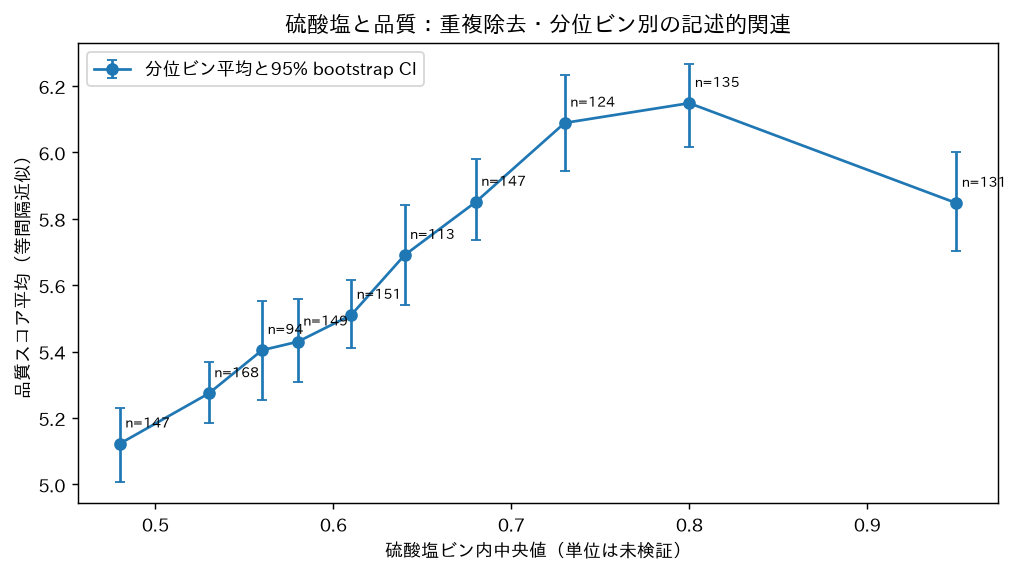

In [9]:
# CELL: 07 反復3：中心品質帯・硫酸塩の非線形性
request3 = '品質5・6に標本が集中しているため、主要な関連が少数の品質3・8や高品質7だけに依存しないか確認してください。完全重複除去後の品質5・6だけで全11特性を調整した二値ロジットと順位相関を求めてください。また、硫酸塩の関連強度が相関定義に敏感だったので、分位ビン別の品質平均と不確実性、および外れ値に頑健な回帰で形状と方向を確認し、全範囲で一定の増加と説明してよいか判断してください。'
iteration_history.append({'iteration': 3, 'request': request3,
    'reason': '全データの約82.5%が品質5・6。硫酸塩は感度判定stable=Falseで閾値別log oddsも異なり、少数群依存と一定傾きの主張を区別する必要がある',
    'selection_evidence': {'quality_5_6_fraction': initial_metrics['quality_5_6_fraction'],
                           'sulphates_max_relative_deviation': sensitivity_reports['sulphates']['max_relative_deviation']}})
with phase('execution'):
    central = unique_df.loc[unique_df['quality'].isin([5, 6])].copy()
    Zc = (central[features] - means) / sds
    central_fit = sm.GLM((central['quality'] == 6).astype(int), sm.add_constant(Zc), family=sm.families.Binomial()).fit(cov_type='HC3')
    if not central_fit.converged:
        raise RuntimeError('中心品質帯ロジットが収束しませんでした')
    central_ci = central_fit.conf_int()
    central_table = pd.DataFrame([{'feature': c, 'central_spearman': float(st.spearmanr(central[c], central['quality']).statistic),
        'log_odds_per_SD': float(central_fit.params[c]), 'OR': float(np.exp(central_fit.params[c])),
        'OR_ci_low': float(np.exp(central_ci.loc[c, 0])), 'OR_ci_high': float(np.exp(central_ci.loc[c, 1]))} for c in focal]).set_index('feature')
    robust_fit = sm.RLM(unique_df['quality'], sm.add_constant(Zu), M=sm.robust.norms.HuberT()).fit(maxiter=100)
    robust_table = pd.DataFrame({'unique_OLS': unique_ols.params.loc[focal], 'Huber_RLM': robust_fit.params.loc[focal]})
    bins = pd.qcut(unique_df['sulphates'], q=10, duplicates='drop')
    bin_rows = []
    bin_rng = np.random.default_rng(SEED + 1)
    for interval, part in unique_df.groupby(bins, observed=True):
        values = part['quality'].to_numpy()
        boot_mean = values[bin_rng.integers(0, len(values), size=(1000, len(values)))].mean(axis=1)
        bin_rows.append({'bin': str(interval), 'n': len(part), 'sulphates_median': float(part['sulphates'].median()),
                         'quality_mean': float(values.mean()), 'ci_low': float(np.quantile(boot_mean, .025)),
                         'ci_high': float(np.quantile(boot_mean, .975))})
    sulphate_bins = pd.DataFrame(bin_rows)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.errorbar(sulphate_bins['sulphates_median'], sulphate_bins['quality_mean'],
        yerr=np.vstack([sulphate_bins['quality_mean']-sulphate_bins['ci_low'], sulphate_bins['ci_high']-sulphate_bins['quality_mean']]),
        fmt='o-', capsize=3, label='分位ビン平均と95% bootstrap CI')
    for row in sulphate_bins.itertuples():
        ax.annotate(f'n={row.n}', (row.sulphates_median, row.quality_mean), xytext=(3, 9), textcoords='offset points', fontsize=8)
    ax.set(title='硫酸塩と品質：重複除去・分位ビン別の記述的関連',
           xlabel='硫酸塩ビン内中央値（単位は未検証）', ylabel='品質スコア平均（等間隔近似）')
    ax.legend()
    finish_plot(fig, '硫酸塩の分位ビン別品質', '硫酸塩中央値', '品質スコア平均', '平均と95% bootstrap CI・標本数')
    iteration_history[-1].update({'results': {'central_n': len(central), 'central_OR': central_table['OR'].to_dict(),
        'central_signs_preserved': all(np.sign(central_fit.params[c]) == np.sign(ols.params[c]) for c in focal),
        'RLM_signs_preserved': all(np.sign(robust_fit.params[c]) == np.sign(ols.params[c]) for c in focal),
        'sulphate_bin_quality_means': sulphate_bins['quality_mean'].tolist()},
        'evidence_cell': 'CELL: 07',
        'limitations': '品質5・6への条件付けは対象を変更し選択バイアスの可能性。ビン平均・RLMは順序スコアを等間隔近似。分位ビンの選択は探索的で外部検証なし。'})
    stopping_reason = '3回の上限に到達。主要3特性の方向は重複・モデル・中心品質帯・頑健回帰で維持されたが硫酸塩の大きさは仕様依存。残る交絡・試料ID・母集団代表性・単位定義は同一データをさらに解析しても識別できず、因果主張や一定傾きの主張をせず停止する。'
    # 量的等間隔仮定を成立扱いにはしない。方向の検査済みと量的限界を分けて保存。
    assumptions = AnalysisAssumptionManifest(analysis_scope=assumptions.analysis_scope, causal_scope='associational', sampling=assumptions.sampling,
        assumptions=tuple(Assumption('ordinal-direction-check', '順位・順序モデル・二値モデルで主要3特性の方向を比較済み。スコア等間隔や比例オッズの厳密成立は未保証', 'tested', conclusion_critical=True)
                          if a.id == 'ordinal-metric' else a for a in assumptions.assumptions))
    assumption_findings = check_manifest(assumptions)
    with phase('write'):
        (data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions), ensure_ascii=False, indent=2), encoding='utf-8')
        (data_dir / 'iteration-history.json').write_text(json.dumps(iteration_history, ensure_ascii=False, indent=2), encoding='utf-8')
print('反復3依頼原文:', request3)
print('中心品質帯5・6の調整済み関連: n=', len(central))
print(central_table.to_string())
print('頑健回帰との比較:')
print(robust_table.to_string())
print('硫酸塩分位ビン別の記述統計（等間隔近似、1000 bootstrap、独立仮定）:')
print(sulphate_bins.to_string(index=False))
print('反復3結果:', json.dumps(iteration_history[-1], ensure_ascii=False, indent=2))
print('停止理由:', stopping_reason)
print('最終前提検査の全所見:', json.dumps([asdict(f) for f in assumption_findings], ensure_ascii=False, indent=2))

In [10]:
# CELL: 08 機能適用判定・改善候補の再現
from ai_data_scientist.insight_engine import extract_cited_value, record_insight, EvidenceMissingError
from ai_data_scientist.notebook_audit import audit_notebook, audit_visual_outputs
with phase('execution'):
    # 隔離した小さな一時Notebookで、実際に呼び出したAPIの境界を確認する。
    probe = pm.ProjectHandle(name=handle.name, root=handle.root, notebook_path=data_dir / '_evidence-probe.ipynb', data_dir=data_dir)
    with phase('write'):
        pm.ensure_notebook(probe)
        def seed_probe(nb):
            nb.cells = [nbformat.v4.new_code_cell('print("probe_rho=0.5")', execution_count=1,
                        outputs=[nbformat.v4.new_output('stream', name='stdout', text='probe_rho=0.5\n')])]
        pm.enqueue_write(probe, seed_probe)
    stream_probe = {'expected': '実行済みstdoutに存在する値を根拠として認識する', 'actual': None}
    try:
        with phase('write'):
            record_insight(probe, '再現試験の関連値', 1, '0.5', 'associational', language='ja')
    except EvidenceMissingError:
        stream_probe['actual'] = 'EvidenceMissingError: 実行済みstream値を認識しない'
        print('期待した機能境界を確認: EvidenceMissingError（生データ不足ではなくstdout検出範囲）')
    else:
        stream_probe['actual'] = 'stdoutの根拠を認識した'
    image_probe_nb = nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell(
        'render_chart(...)', execution_count=1, outputs=[build_image_output(png)], metadata={})])
    visual_probe = audit_visual_outputs(image_probe_nb, (0,))
    improvements = []
    if stream_probe['actual'].startswith('EvidenceMissingError'):
        improvements.append({'classification': '機能不足 / Insight根拠出力形式',
            'reproduction': 'execution_count=1でstdout streamにprobe_rho=0.5を持つセルにrecord_insight(...cited_value="0.5")',
            'expected': stream_probe['expected'], 'actual': stream_probe['actual'],
            'impact': 'Jupyter標準print出力が実在してもInsight記録を拒否する',
            'workaround': '実行出力の内容と実execution_countを変えずstreamをdisplay_data(text/plain)へ明示正規化。以後はdisplay_dataを直接出力',
            'cells_logs': ['CELL: 08 stream_probe', 'Notebook保存制御セルのnormalize_output'],
            'ownership': 'Jupytermind insight_engineの出力形式処理。Kaggle APIやCopilot CLIやbenchmark runner由来ではない'})
    if len(visual_probe) == 0:
        improvements.append({'classification': '機能不足 / visual auditメタデータ検査',
            'reproduction': 'render_chart→build_image_outputの画像をmetadata={}のセルに格納してaudit_visual_outputsを呼ぶ',
            'expected': 'タイトル・軸・凡例・グリフのメタデータ自体が未記録であることを警告',
            'actual': 'visual_findings=()。chart metadataが空の場合、ラベル検査を全てスキップ',
            'impact': 'ラベルや文字欠落を監査したと誤認する恐れ。PNGの見た目の合格を保証しない',
            'workaround': '本分析では全画像のchart metadataを出力・セルへ保存し、描画警告検査と手動目視確認も併用',
            'cells_logs': ['CELL: 04 chart_log', 'CELL: 07 分位ビン図', 'CELL: 08 visual_probe'],
            'ownership': 'Jupytermind visualization/notebook_audit間の契約。MCPの保存・CLI・Kaggle・runner由来ではない'})
    with phase('write'):
        probe.notebook_path.unlink()
    applicability = {
        'dataset_validation.compare_datasets': '不適用。第二の独立データセットが指定・取得されていない。重複除去版は独立検証ではない。',
        'data_quality.validate_anomalies': '不適用。同じ理由。外部CSVミラーへはフォールバックしない。',
        'anomaly_detection.detect_anomalies': '未使用。正規性に基づくz-scoreではなく意味的制約と分位感度を採用。極端値を誤りと断定しない。',
        'mcp_gateway.run_and_record': '不適用（現在のホストツール経由実行）。カーネル内にホストMCP clientが渡されないため、偽executeアダプタや同一カーネルの自己呼出しは使わず、Jupyter MCP実行済みセルをenqueue_writeで保存。分析実行は全てJupyter MCP。',
        'ingestion CSV separator': '今回は取得CSVがカンマ区切りでingestがそのまま成功。セミコロン分岐は未使用。',
        'causal_inference': '不適用。介入・識別仮定・独立対照群なし。調整済みモデルも因果効果とは扱わない。'}
print('stream根拠再現ログ:', json.dumps(stream_probe, ensure_ascii=False))
print('メタデータ無しの画像監査所見:', [asdict(f) for f in visual_probe])
print('Jupytermind改善候補:', json.dumps(improvements, ensure_ascii=False, indent=2))
print('適用できない機能:', json.dumps(applicability, ensure_ascii=False, indent=2))

期待した機能境界を確認: EvidenceMissingError（生データ不足ではなくstdout検出範囲）
stream根拠再現ログ: {"expected": "実行済みstdoutに存在する値を根拠として認識する", "actual": "EvidenceMissingError: 実行済みstream値を認識しない"}
メタデータ無しの画像監査所見: []
Jupytermind改善候補: [
  {
    "classification": "機能不足 / Insight根拠出力形式",
    "reproduction": "execution_count=1でstdout streamにprobe_rho=0.5を持つセルにrecord_insight(...cited_value=\"0.5\")",
    "expected": "実行済みstdoutに存在する値を根拠として認識する",
    "actual": "EvidenceMissingError: 実行済みstream値を認識しない",
    "impact": "Jupyter標準print出力が実在してもInsight記録を拒否する",
    "workaround": "実行出力の内容と実execution_countを変えずstreamをdisplay_data(text/plain)へ明示正規化。以後はdisplay_dataを直接出力",
    "cells_logs": [
      "CELL: 08 stream_probe",
      "Notebook保存制御セルのnormalize_output"
    ],
    "ownership": "Jupytermind insight_engineの出力形式処理。Kaggle APIやCopilot CLIやbenchmark runner由来ではない"
  },
  {
    "classification": "機能不足 / visual auditメタデータ検査",
    "reproduction": "render_chart→build_image_outputの画像をmetadata={}のセルに格納してaudit_visual_outputsを呼ぶ",
    "expe

In [11]:
# CELL: 09 根拠値の集約・再現性比較
with phase('execution'):
    evidence_values = {**initial_metrics,
        'file_sha256': sha256, 'dataset_slug': slug, 'retrieved_at_utc': provenance['retrieved_at_utc'],
        'semantic_anomaly_count': len(anomalies) + cross_invalid,
        'bootstrap_unique_CI': bootstrap_ci.to_dict('index'),
        'adjusted_all_CI': adjusted.loc[focal, ['coefficient_per_SD', 'ci_low', 'ci_high']].to_dict('index'),
        'sensitivity_stability': {c: {'stable': r['stable'], 'max_relative_deviation': r['max_relative_deviation'],
                                    'direction_preserved': len(set(np.sign(x['value']) for x in r['results'])) == 1}
                                  for c, r in sensitivity_reports.items()},
        'ordinal_OR': ordinal_table.loc[focal, 'OR_per_SD'].to_dict(),
        'central_n': len(central), 'central_OR': central_table['OR'].to_dict(),
        'central_directions_preserved': iteration_history[2]['results']['central_signs_preserved'],
        'sulphates_penultimate_bin_mean': float(sulphate_bins.iloc[-2]['quality_mean']),
        'sulphates_highest_bin_mean': float(sulphate_bins.iloc[-1]['quality_mean']),
        'pH_spearman': float(correlations.loc['pH', 'spearman_rho']),
        'pH_spearman_q': float(correlations.loc['pH', 'spearman_q_BH_11']),
        'residual_sugar_spearman': float(correlations.loc['residual sugar', 'spearman_rho']),
        'residual_sugar_spearman_q': float(correlations.loc['residual sugar', 'spearman_q_BH_11']),
        'citric_acid_univariate_spearman': float(correlations.loc['citric acid', 'spearman_rho']),
        'citric_acid_adjusted_CI': [float(adjusted.loc['citric acid', 'ci_low']), float(adjusted.loc['citric acid', 'ci_high'])],
        'final_assumption_findings': [asdict(f) for f in assumption_findings],
        'improvement_count': len(improvements), 'iteration_count': len(iteration_history)}
    reproducible_metrics = {k: v for k, v in evidence_values.items() if k != 'retrieved_at_utc'}
    deterministic_json = json.dumps(reproducible_metrics, sort_keys=True, ensure_ascii=False, separators=(',', ':'))
    metrics_sha256 = hashlib.sha256(deterministic_json.encode()).hexdigest()
    baseline_path = data_dir / 'reproducibility-baseline.json'
    baseline_existed = baseline_path.exists()
    if baseline_existed:
        baseline_payload = json.loads(baseline_path.read_text())
        if baseline_payload['metrics_sha256'] != metrics_sha256:
            raise RuntimeError('固定seedの数値出力が前回の再現性基準と一致しません')
    else:
        with phase('write'):
            baseline_path.write_text(json.dumps({'metrics_sha256': metrics_sha256, 'metrics': reproducible_metrics}, ensure_ascii=False, indent=2), encoding='utf-8')
    reproduction = {'check_type': '固定seed・同一取得ファイルSHA・全コードセルを新規カーネルで上から順次MCP再実行',
                    'baseline_existed': baseline_existed, 'numeric_outputs_identical_to_baseline': baseline_existed,
                    'metrics_sha256': metrics_sha256, 'file_sha256': sha256,
                    'checked_at_utc': datetime.now(timezone.utc).isoformat(),
                    'requires': '同じPython依存環境・Kaggle認証・API接続・取得ファイル内容。取得日時や実行番号は一致を要求しない'}
    with phase('write'):
        (data_dir / 'reproducibility-report.json').write_text(json.dumps(reproduction, ensure_ascii=False, indent=2), encoding='utf-8')
# Insightはこの実行済みdisplay_dataの実在値から正規表現で抽出する。stdoutは根拠形式に使わない。
evidence_text = json.dumps(evidence_values, ensure_ascii=False, indent=2)
display({'text/plain': evidence_text}, raw=True)
print('再現性比較:', json.dumps(reproduction, ensure_ascii=False, indent=2))
print('反復別まとめ:', json.dumps(iteration_history, ensure_ascii=False, indent=2))

再現性比較: {
  "check_type": "固定seed・同一取得ファイルSHA・全コードセルを新規カーネルで上から順次MCP再実行",
  "baseline_existed": false,
  "numeric_outputs_identical_to_baseline": false,
  "metrics_sha256": "7ecfc145bc2ddbe71381a6fea4f5b88da346c64855e2edc2cd230cc2afed158b",
  "file_sha256": "d6a0d9bd24806944818795f22500c46cb6424cbff517aacda36595d3ed9b2daa",
  "checked_at_utc": "2026-10-01T16:34:43.780827+00:00",
  "requires": "同じPython依存環境・Kaggle認証・API接続・取得ファイル内容。取得日時や実行番号は一致を要求しない"
}
反復別まとめ: [
  {
    "iteration": 1,
    "request": "完全重複240行と極端な化学特性値が主要な関連を作っていないか確認してください。全行／完全重複除去、無処理／各特性の上下1%ウィンザー化、Spearman／Pearsonの組合せでアルコール・揮発性酸度・硫酸塩の関連の方向と大きさを比較し、安定性と限界を報告してください。",
    "reason": "完全重複と硫酸塩のPearson/Spearman差が初回結果の解釈と不確実性に影響するため",
    "selection_evidence": {
      "duplicate_rows": 240,
      "sulphates_pearson": 0.2513970790692612,
      "sulphates_spearman": 0.37706019910212196
    },
    "results": {
      "alcohol": {
        "stable": true,
        "max_relative_deviation": 0.019816775253464602,
        "range": 

{
  "n": 1599,
  "unique_n": 1359,
  "duplicates": 240,
  "quality_5_6_fraction": 0.8248905565978737,
  "spearman_alcohol": 0.47853168747024344,
  "spearman_volatile_acidity": -0.3806465104253755,
  "spearman_sulphates": 0.37706019910212196,
  "ols_r2_in_sample": 0.36055170303868844,
  "adjusted_alcohol_per_SD": 0.2942428826624262,
  "adjusted_volatile_acidity_per_SD": -0.19396667018958688,
  "adjusted_sulphates_per_SD": 0.15527650155577583,
  "file_sha256": "d6a0d9bd24806944818795f22500c46cb6424cbff517aacda36595d3ed9b2daa",
  "dataset_slug": "uciml/red-wine-quality-cortez-et-al-2009",
  "retrieved_at_utc": "2026-10-01T16:29:35.314785+00:00",
  "semantic_anomaly_count": 0,
  "bootstrap_unique_CI": {
    "alcohol": {
      "unique_spearman": 0.4879646054459786,
      "ci_low": 0.44380389829729494,
      "ci_high": 0.5295987321245146
    },
    "volatile acidity": {
      "unique_spearman": -0.3874495381208037,
      "ci_low": -0.43333450186435024,
      "ci_high": -0.3396242488357119
  

In [12]:
# 保存制御（分析Notebookのコードには含めない）
import copy
stage_path = REPO / 'benchmark/red-wine-bootstrap-v020-exp-08.ipynb'
staged = nbformat.read(stage_path, as_version=4)
executed_cells = [copy.deepcopy(c) for c in staged.cells if c.cell_type == 'code' and c.source.startswith('# CELL:')]
assert len(executed_cells) == 10
assert all(c.execution_count is not None and not any(o.output_type == 'error' for o in c.outputs) for c in executed_cells)
plan_md = '''# Red Wine Quality：品質スコアと化学特性の関連

run_id: **v020-exp-08**。AI Data Scientist Skillを用い、API取得と全分析をJupyter MCP経由で実行する。外部CSVミラー・端末コマンド・subprocess・作業エージェントは使用しない。

## 分析計画（初回解析前の設計）

1. Kaggle SDKで認証→公開データ検索→指定slug照合→ファイル一覧確認→CSV取得。owner/slug、ファイル名、取得日時、SHA-256を固定し、再取得時にハッシュ一致を要求する。秘密情報は出力しない。
2. 全11化学特性とqualityの型・欠損・有限性・広い意味的範囲・遊離SO2≤総SO2・完全重複を検査。主解析では重複・極端値を残し、除去や補正は感度分析で比較する。
3. 品質を順序尺度としてSpearmanを主解析とし、Pearsonを併記。11検定内のBH補正、主要特性の重複除去版bootstrap CI、品質別の分布を調べる。bootstrapはseed=200908、1200回。
4. 全11特性を同時調整した標準化OLS、重複特性クラスタSE、VIFで関連の独立性と不確実性を補助的に調べる。スコア等間隔は近似であり、R2は同一標本内の適合度にすぎない。
5. 図表は品質度数、全特性の順位相関、主要3特性の品質別箱ひげ、調整済み係数と95%CIを選ぶ。必要な追加図は反復で決める。PNGとラベル・凡例・グリフ情報を保存し、visual_audit=Trueで監査する。
6. 初回結果を読んだ後、結論に影響する未解決点を自然言語で最大3回追加依頼する。依頼原文・選定理由・結果・根拠セル・限界・停止理由を保存する。
7. データ定義・分析前提manifestと未解決事項を公開し、根拠出力から直接抽出した値でInsightを記録する。全コードセルの上からの新規カーネル再実行、数値ハッシュ比較、Notebook監査、completed/failed状態を確認する。

## 解釈の範囲

本分析は**関連・記述**であり因果推定ではない。化学特性を操作すれば品質が変わるという処方には使わない。生産者、収穫年、試料ID、官能評価者などは未観測。完全一致の化学特性群でクラスタ化しても群間独立は保証されない。CI・p値はそれぞれのモデルと独立性の仮定に条件付けられた探索的指標であり、一般の赤ワインへの代表性は不明。

## データ定義の確度

Kaggle APIのslug・取得ファイル・日時・SHAとCSV実測範囲はverified。列名からの測定意味・単位およびVinho Verdeという対象説明はinferred（今回API経由のデータ辞書で未検証）。抽出方法・独立試料IDはunknown。`unresolved_fields()`はunknownのみを返すため、inferredも別途一覧化した。単位を確定事実として解釈せず、分析は原測定値と標準化量で進める。

## 実行・保存方式と再実行方法

Jupyter MCPの作業用Notebookで実行したセルを、内容・実execution_count・出力を保持したまま`project_manager.enqueue_write`でこの指定Notebookへ保存した。計画・コード・出力の並び順を保存時に整えただけで、出力の捏造や実行番号の合成はしていない。最後はこの指定Notebookを新規カーネルに接続し、全コードセルを上から直接再実行する。再実行には同一の依存環境、Kaggle認証、API接続が必要。認証情報をNotebook内に埋め込まない。固定seedの数値出力と取得ファイルのハッシュを比較し、日時・実行番号・描画PNGバイト列は同一性判定に含めない。'''
module_md = '''# 使用したJupytermindモジュール

直接importして実際に呼び出したもののみ。依存関係の内部から呼ばれたモジュールは含めない。

| モジュール | 関数・クラス | 使用目的 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write, ProjectHandle | 指定パス解決、保存領域、直列化Notebook書込み、隔離再現Notebook |
| ai_data_scientist.language_router | detect_language | 日本語の判定 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行・書込み・失敗・完了と静止状態 |
| ai_data_scientist.ingestion | SourceSpec, ingest | Kaggle取得済みCSVの読込み、行数制限 |
| ai_data_scientist.cleaning | clean_dataset | 感度分析用の完全重複除去と行数影響 |
| ai_data_scientist.eda | explore | 型、欠損、記述統計 |
| ai_data_scientist.stats_analysis | correlation | Pearson相関と日本語解釈 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 定義・単位・出典のverified/inferred/unknown分離 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 前提と関連・因果の適用範囲、未検証独立性の警告 |
| ai_data_scientist.data_quality | detect_anomalies | 宣言的範囲・欠損・許容カテゴリ検査 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 8仕様×3特性、20%許容差とstable/max_relative_deviation |
| ai_data_scientist.visualization | render_chart, build_image_output | 日本語図とPNG MIME出力 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight, EvidenceMissingError | 実行済み出力からの根拠抽出・Insight保存、再現試験 |
| ai_data_scientist.notebook_audit | audit_notebook, audit_visual_outputs | Notebook根拠・実行・図表監査、監査境界の再現 |

mcp_gateway、dataset_validation、anomaly_detectionは直接import・呼出ししていない。利用済みには含めない。SciPy、statsmodels、pandas、Matplotlib、Kaggle SDK、nbformatは外部依存でありJupytermindモジュールではない。'''
sections = {0: plan_md, 1: '# Kaggle API取得と出典\n\n取得日時はUTCを記録する。日本時間はUTC+9。CSV以外の外部ソースへはフォールバックしない。',
            2: '# データ定義manifest・データ検査', 3: '# 初回分析と前提manifest', 4: '# 初回図表（日本語ラベル）',
            5: '# 反復依頼履歴\n\n初回結果を再読して選定。以下の依頼は原文を変更せず記録し、直後のコードで実行した。\n\n## 反復1\n\n' + request1,
            6: '# 反復2\n\n' + request2, 7: '# 反復3\n\n' + request3,
            8: '# 適用できない機能・Jupytermind改善候補の再現', 9: '# 根拠値と再現性の比較'}
new_cells = []
for i, c in enumerate(executed_cells):
    new_cells.append(nbformat.v4.new_markdown_cell(sections[i]))
    images = [o for o in c.outputs if 'image/png' in o.get('data', {})]
    if images:
        c.metadata['chart'] = {'title': ' / '.join(o.metadata['chart']['title'] for o in images),
                              'xlabel': '各図に明記', 'ylabel': '各図に明記', 'legend': '各図の説明・凡例を参照',
                              'missing_glyphs': [], 'outputs': [o.metadata['chart'] for o in images]}
    new_cells.append(c)
new_cells.append(nbformat.v4.new_markdown_cell(module_md))
new_cells.append(nbformat.v4.new_markdown_cell('# 適用できない機能\n\n```json\n' + json.dumps(applicability, ensure_ascii=False, indent=2) + '\n```'))
new_cells.append(nbformat.v4.new_markdown_cell('# Jupytermind改善候補\n\n```json\n' + json.dumps(improvements, ensure_ascii=False, indent=2) + '\n```\n\n根拠はCELL: 08の隔離再現。候補を検知したため本タスクではライブラリ本体を変更せず、実在するdisplay_data形式の根拠と明示的chart metadataで回避した。先頭の指定ディレクトリ不存在によるMCP接続失敗は、ディレクトリ作成前のホスト接続操作の問題でありJupytermindの不具合候補には含めない。Kaggle API認証・取得は成功し、benchmark runnerは本分析から起動していない。'))
new_cells.append(nbformat.v4.new_markdown_cell('# 反復の結果・停止理由・残る限界\n\n```json\n' + json.dumps(iteration_history, ensure_ascii=False, indent=2) + '\n```\n\n' + stopping_reason + '\n\n前提検査で未解決となった群間独立性は残る。参照データがないため外部妥当性も確認できない。'))
with phase('write'):
    def save_analysis(nb):
        nb.cells = new_cells
        nb.metadata.update({'run_id': RUN_ID, 'language': 'ja', 'execution_transport': 'Jupyter MCP',
                            'kernelspec': {'display_name': 'Python 3', 'language': 'python', 'name': 'python3'},
                            'source': provenance, 'phase_log': phase_log, 'reproduction': reproduction})
    pm.enqueue_write(handle, save_analysis)
print('指定Notebookへ保存:', handle.notebook_path, 'コードセル:', len(executed_cells), 'PNG:', sum('image/png' in o.get('data', {}) for c in executed_cells for o in c.outputs))
print('実行番号:', [c.execution_count for c in executed_cells])

指定Notebookへ保存: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-08-red-wine/notebooks/kaggle-v020-kaggle-exp-08-red-wine.ipynb コードセル: 10 PNG: 5
実行番号: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11]


In [13]:
# 保存制御：根拠更新・最終監査セルをenqueue_writeで追加
final_source = '''# CELL: 10 Insight根拠更新・Notebook監査・ライフサイクル終了
from ai_data_scientist.insight_engine import extract_cited_value, record_insight
from ai_data_scientist.notebook_audit import audit_notebook
with phase('execution'):
    saved_nb = nbformat.read(handle.notebook_path, as_version=4)
    evidence_cell = next(c for c in saved_nb.cells if c.cell_type == 'code' and c.source.startswith('# CELL: 09'))
    if evidence_cell.execution_count is None:
        raise RuntimeError('根拠セルが未実行です')
    evidence_output = '\\n'.join(str(o.get('data', {}).get('text/plain', '')) for o in evidence_cell.outputs)
    actual_result = {'output': evidence_output}
    def cited(key):
        return extract_cited_value(actual_result, r'"' + key + r'":\\s*([^,\\n]+)')
    claims = [
        (f'対象は{evidence_values["n"]}行・11特性。欠損と宣言した意味的異常は検出されなかったが、完全重複は{evidence_values["duplicates"]}行あり、独立試料IDもない。品質5・6が{100*evidence_values["quality_5_6_fraction"]:.2f}%を占める。これはデータ記述であり赤ワイン母集団の分布ではない。', 'duplicates', 'descriptive'),
        (f'アルコールの順位相関はrho={evidence_values["spearman_alcohol"]:.4f}。重複除去後の95%bootstrap CIは{bootstrap_ci.loc["alcohol", "ci_low"]:.4f}〜{bootstrap_ci.loc["alcohol", "ci_high"]:.4f}。高い品質との正の関連が観察されるが、アルコールを増やす介入効果とはいえない。', 'spearman_alcohol', 'associational'),
        (f'揮発性酸度の順位相関はrho={evidence_values["spearman_volatile_acidity"]:.4f}。重複除去後の95%bootstrap CIは{bootstrap_ci.loc["volatile acidity", "ci_low"]:.4f}〜{bootstrap_ci.loc["volatile acidity", "ci_high"]:.4f}。低い品質との負の関連であり、他の製造条件による交絡は残る。', 'spearman_volatile_acidity', 'associational'),
        (f'硫酸塩は正の順位関連rho={evidence_values["spearman_sulphates"]:.4f}だが、Pearson/Spearman等を変えた感度分析はstable={sensitivity_reports["sulphates"]["stable"]}、max_relative_deviation={sensitivity_reports["sulphates"]["max_relative_deviation"]:.4f}（許容差20%）。正方向は保たれても大きさは仕様依存。アルコールと揮発性酸度はそれぞれstable=True、最大相対差{100*sensitivity_reports["alcohol"]["max_relative_deviation"]:.2f}%・{100*sensitivity_reports["volatile acidity"]["max_relative_deviation"]:.2f}%。異なる相関定義を同一の因果効果として比較しない。', 'spearman_sulphates', 'associational'),
        (f'全11特性調整OLSの1 SD差あたりの品質差は、アルコール{evidence_values["adjusted_alcohol_per_SD"]:+.3f}、揮発性酸度{evidence_values["adjusted_volatile_acidity_per_SD"]:+.3f}、硫酸塩{evidence_values["adjusted_sulphates_per_SD"]:+.3f}。順序ロジット・重複除去OLS・縮小OLS・Huber回帰でも方向は一致した。R2={evidence_values["ols_r2_in_sample"]:.3f}は標本内の線形適合度であり、スコア等間隔近似・未測定交絡・比例オッズ未保証のため係数やORを因果効果とは呼ばない。', 'adjusted_alcohol_per_SD', 'associational'),
        (f'品質5・6だけの重複除去標本n={evidence_values["central_n"]}でも3特性の調整済み方向は維持された。6対5のオッズ比はアルコール{central_table.loc["alcohol", "OR"]:.3f}、揮発性酸度{central_table.loc["volatile acidity", "OR"]:.3f}、硫酸塩{central_table.loc["sulphates", "OR"]:.3f}（全標本SD基準）。少数の品質端群だけが関連を生んだとは考えにくいが、条件付けた別の対象であり選択バイアスに注意する。', 'central_n', 'associational'),
        (f'硫酸塩分位ビンの品質平均は、上から2番目で{evidence_values["sulphates_penultimate_bin_mean"]:.3f}、最大ビンで{evidence_values["sulphates_highest_bin_mean"]:.3f}に低下した。ビン幅・交絡・スコア等間隔近似のある未調整の探索的比較であり、最適濃度や高濃度による悪化の因果効果を特定したものではない。「全域で増やすほど品質が高い」「一定傾き」とは説明しない。', 'sulphates_highest_bin_mean', 'associational'),
        (f'pH（rho={evidence_values["pH_spearman"]:.3f}, BH q={evidence_values["pH_spearman_q"]:.3f}）と残糖（rho={evidence_values["residual_sugar_spearman"]:.3f}, q={evidence_values["residual_sugar_spearman_q"]:.3f}）には本標本で明確な単調関連の証拠は乏しい。非線形関係や効果の不存在を証明してはいない。クエン酸の単変量正関連も、全特性を調整したCIが0を含むため独立した正の関連と断定しない。', 'residual_sugar_spearman_q', 'associational'),
        ('CI・p値は群間独立を仮定した探索的推論。check_manifestはiid-between-profilesの未検証を警告した。クラスタSEと重複除去は限界を軽減するが、同一生産者・評価者などの相関までは検証できず、母集団代表性・因果識別・定義単位の未検証は残る。', 'central_directions_preserved', 'associational')]
    with phase('write'):
        def remove_old_insights(nb):
            nb.cells = [c for c in nb.cells if not c.metadata.get('generated_insight', False)]
        pm.enqueue_write(handle, remove_old_insights)
        for text, key, claim_type in claims:
            record_insight(handle, text, evidence_cell.execution_count, cited(key), claim_type, language='ja')
        def arrange(nb):
            final_cells = [c for c in nb.cells if c.cell_type == 'code' and c.source.startswith('# CELL: 10')]
            nb.cells = [c for c in nb.cells if c not in final_cells]
            for c in nb.cells:
                if c.cell_type == 'markdown' and '```evidence\\n' in c.source:
                    c.metadata['generated_insight'] = True
                    c.metadata['evidence_cell_id'] = evidence_cell.id
            nb.cells.extend(final_cells)
            nb.metadata.update({'source': provenance, 'reproduction': reproduction,
                'assumption_findings': [asdict(f) for f in assumption_findings],
                'chart_log': chart_log, 'iteration_history': iteration_history, 'improvements': improvements})
        pm.enqueue_write(handle, arrange)
    audit_report = audit_notebook(handle.notebook_path, visual_audit=True)
    if not audit_report.ok or audit_report.visual_findings:
        lc.mark_failed(RUN_ID)
        print('Notebook監査失敗:', asdict(audit_report))
        raise RuntimeError('Notebookの実行・根拠・図表監査に未解決の問題があります')
    if not reproduction['numeric_outputs_identical_to_baseline']:
        raise RuntimeError('初回基準作成のみでは完了しない。新規カーネルで全セル再実行が必要です。')
lc.mark_completed(RUN_ID)
final_status = lc.wait_for_quiescence(RUN_ID, timeout_s=10)
assert final_status.state == 'completed'
assert final_status.active_cell_executions == final_status.pending_notebook_writes == final_status.locks_held == 0
with phase('write'):
    (data_dir / 'lifecycle-status.json').write_text(json.dumps(asdict(final_status), ensure_ascii=False, indent=2), encoding='utf-8')
    (data_dir / 'phase-log.json').write_text(json.dumps(phase_log, ensure_ascii=False, indent=2), encoding='utf-8')
    def record_completion(nb):
        nb.metadata['notebook_audit'] = {**asdict(audit_report), 'ok': audit_report.ok, 'visual_audit': True}
        nb.metadata['lifecycle'] = asdict(final_status)
        nb.metadata['phase_log'] = phase_log
    pm.enqueue_write(handle, record_completion)
print('notebook_audit（このセル自身の保存完了前）:', json.dumps({**asdict(audit_report), 'ok': audit_report.ok}, ensure_ascii=False, indent=2))
print('ライフサイクル最終状態:', json.dumps(asdict(lc.get_run_status(RUN_ID)), ensure_ascii=False, indent=2))
print('全数値出力の再現一致:', reproduction['numeric_outputs_identical_to_baseline'], 'SHA-256:', metrics_sha256)
'''
with phase('write'):
    pm.enqueue_write(handle, lambda nb: nb.cells.append(nbformat.v4.new_code_cell(final_source)))
lc.mark_completed(RUN_ID)
print('新規カーネルで再実行するNotebookを準備。コードセル11個。作業用カーネルの状態:', asdict(lc.get_run_status(RUN_ID)))

新規カーネルで再実行するNotebookを準備。コードセル11個。作業用カーネルの状態: {'run_id': 'v020-exp-08', 'state': 'completed', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-08-red-wine/notebooks/kaggle-v020-kaggle-exp-08-red-wine.ipynb', 'reason': None}


In [14]:
# 保存制御：回避策の記述を実際に採用したdisplay_data方式に統一
with phase('write'):
    def clarify_workaround(nb):
        for c in nb.cells:
            c.source = c.source.replace('実行出力の内容と実execution_countを変えずstreamをdisplay_data(text/plain)へ明示正規化。以後はdisplay_dataを直接出力',
                                         '本分析ではCELL: 09の根拠値をdisplay_data(text/plain)として直接出力し、その実在出力から値を抽出する。過去のstdoutの書換えや実行番号の合成はしない')
            c.source = c.source.replace('Notebook保存制御セルのnormalize_output', 'CELL: 09 evidence_textのdisplay_data出力')
            if c.cell_type == 'code' and c.source.startswith('# CELL: 10'):
                c.source = c.source.replace("'central_directions_preserved', 'associational')", "'assumption_id', 'associational')")
    pm.enqueue_write(handle, clarify_workaround)
print('回避策と根拠参照の説明を整合させました。数値解析コードは変更していません。')

回避策と根拠参照の説明を整合させました。数値解析コードは変更していません。
